In [1]:
!git clone https://github.com/CosmoIknosLab/NuLite.git
%cd NuLite

Cloning into 'NuLite'...
remote: Enumerating objects: 278, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 278 (delta 10), reused 14 (delta 4), pack-reused 245 (from 1)
Receiving objects: 100% (278/278), 102.27 MiB | 8.41 MiB/s, done.
Resolving deltas: 100% (58/58), done.
/content/NuLite


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/data_processed /content/data_processed

%cd /content/NuLite

Mounted at /content/drive
cp: cannot stat '/content/drive/MyDrive/data_processed': No such file or directory
/content/NuLite


In [16]:
from google.colab import drive
drive.mount('/content/drive')


!find /content/drive/MyDrive -name "data_procesed" -type d 2>/dev/null

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
!find /content/drive/MyDrive -name "data_proces*" -type d 2>/dev/null

/content/drive/MyDrive/data_processed


In [18]:
!cp -rL /content/drive/MyDrive/data_processed /content/data_processed

In [19]:

!pip install timm albumentations scikit-image torchinfo wandb pandas scipy numba natsort opencv-python -q

In [21]:

import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [22]:

!python train_cell_segmentation.py \
  --config configs/pannuke.yaml \
  --gpu 0

python3: can't open file '/content/NuLite/train_cell_segmentation.py': [Errno 2] No such file or directory


In [23]:
!ls /content/NuLite/

base_ml		 LICENSE	   README.md		 train_nulite.py
config_examples  models		   requirements.txt	 utils
configs		 nuclei_detection  run_inference_wsi.py  wsi_example
docs		 preprocessing	   sanitizy_weights.py


In [24]:
!python train_nulite.py --help

Traceback (most recent call last):
  File "/content/NuLite/train_nulite.py", line 5, in <module>
    from nuclei_detection.experiments.experiment_nulite_pannuke import ExperimentNuLitePanNuke
  File "/content/NuLite/nuclei_detection/experiments/experiment_nulite_pannuke.py", line 20, in <module>
    from nuclei_detection.training.nulite_trainer import NuLiteTrainer
  File "/content/NuLite/nuclei_detection/training/nulite_trainer.py", line 23, in <module>
    from torchmetrics.functional import dice
ModuleNotFoundError: No module named 'torchmetrics'


In [25]:
!pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 31.1 MB/s eta 0:00:00


In [26]:
!python train_nulite.py --help

Traceback (most recent call last):
  File "/content/NuLite/train_nulite.py", line 5, in <module>
    from nuclei_detection.experiments.experiment_nulite_pannuke import ExperimentNuLitePanNuke
  File "/content/NuLite/nuclei_detection/experiments/experiment_nulite_pannuke.py", line 20, in <module>
    from nuclei_detection.training.nulite_trainer import NuLiteTrainer
  File "/content/NuLite/nuclei_detection/training/nulite_trainer.py", line 23, in <module>
    from torchmetrics.functional import dice
ImportError: cannot import name 'dice' from 'torchmetrics.functional' (/usr/local/lib/python3.12/dist-packages/torchmetrics/functional/__init__.py)


In [27]:
!pip install torchmetrics==0.11.4 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.2/519.2 kB 20.8 MB/s eta 0:00:00


In [29]:
!pip install schema -q

In [30]:
!python train_nulite.py --help

usage: train_nulite.py [-h] --config CONFIG [--gpu GPU]
                       [--checkpoint CHECKPOINT]

Start an experiment with given configuration file.

options:
  -h, --help            show this help message and exit
  --gpu GPU             Cuda-GPU ID (default: None)
  --checkpoint CHECKPOINT
                        Path to a PyTorch checkpoint file. The file is loaded
                        and continued to train with the provided settings. If
                        this is passed, no sweeps are possible. This parameter
                        cannot be set in the config file! (default: None)

required named arguments:
  --config CONFIG       Path to a config file (default: None)


In [31]:
!ls /content/NuLite/configs/

datasets  __init__.py  python


In [32]:
!ls /content/NuLite/configs/datasets/

PanNuke


In [33]:
!ls /content/NuLite/configs/datasets/PanNuke/

dataset_config.yaml  fold0  fold1  fold2  weight_config.yaml


In [34]:
!ls /content/NuLite/configs/datasets/PanNuke/fold0/

cell_count.csv	types.csv


In [35]:
!ls /content/NuLite/configs/python/

config.py  __init__.py


In [36]:
!cp -r /content/data_processed/fold0 /content/NuLite/data/fold0
!cp -r /content/data_processed/fold1 /content/NuLite/data/fold1
!cp -r /content/data_processed/fold2 /content/NuLite/data/fold2
!cp /content/data_processed/dataset_config.yaml /content/NuLite/configs/datasets/PanNuke/dataset_config.yaml
!cp /content/data_processed/weight_config.yaml /content/NuLite/configs/datasets/PanNuke/weight_config.yaml

cp: cannot stat '/content/data_processed/fold0': No such file or directory
cp: cannot stat '/content/data_processed/fold1': No such file or directory
cp: cannot stat '/content/data_processed/fold2': No such file or directory
cp: cannot stat '/content/data_processed/dataset_config.yaml': No such file or directory
cp: cannot stat '/content/data_processed/weight_config.yaml': No such file or directory


In [37]:
!find /content/drive/MyDrive -name "fold0" -type d 2>/dev/null
!find /content -name "fold0" -type d 2>/dev/null

/content/data_processed/data_processed/fold0
/content/NuLite/configs/datasets/PanNuke/fold0
/content/drive/.shortcut-targets-by-id/1OLzbTSFLC5Pl5eGp1sAV0pFxOS0oJdfx/data_processed/fold0


In [39]:
!mkdir -p /content/NuLite/data
!cp -r /content/data_processed/data_processed/fold0 /content/NuLite/data/fold0
!cp -r /content/data_processed/data_processed/fold1 /content/NuLite/data/fold1
!cp -r /content/data_processed/data_processed/fold2 /content/NuLite/data/fold2
!cp /content/data_processed/data_processed/dataset_config.yaml /content/NuLite/configs/datasets/PanNuke/dataset_config.yaml
!cp /content/data_processed/data_processed/weight_config.yaml /content/NuLite/configs/datasets/PanNuke/weight_config.yaml

In [40]:
!ls /content/NuLite/configs/python/

config.py  __init__.py


In [41]:
!cat /content/NuLite/configs/python/config.py

# -*- coding: utf-8 -*-
# Internal Config
#
# @ Fabian Hörst, fabian.hoerst@uk-essen.de
# Institute for Artifical Intelligence in Medicine,
# University Medicine Essen

from typing import List, Dict, Tuple

WSI_EXT: List[str] = [
    "svs",
    "tiff",
    "tif",
    "bif",
    "scn",
    "ndpi",
    "vms",
    "vmu",
]  # mirax not tested yet
ANNOTATION_EXT: List[str] = ["json"]
LOGGING_EXT: List[str] = ["critical", "error", "warning", "info", "debug"]
BACKBONES: List[str] = ["ResNet50", "ResNet50Bottleneck", "ResNet18", "ResNet34"]

# Currently: 30 Colors
COLOR_DEFINITIONS: Dict[int, Tuple[int]] = {
    0: (239, 71, 111),
    1: (255, 209, 102),
    2: (6, 214, 160),
    3: (7, 59, 76),
    4: (255, 190, 11),
    5: (251, 86, 7),
    6: (255, 0, 110),
    7: (131, 56, 236),
    8: (58, 134, 255),
    9: (249, 65, 68),
    10: (243, 114, 44),
    11: (248, 150, 30),
    12: (249, 132, 74),
    13: (249, 199, 79),
    14: (144, 190, 109),
    15: (67, 170, 139),
    16: (77, 144, 142),

In [42]:
!ls /content/NuLite/config_examples/

preprocessing_example.yaml  training_example.yaml


In [44]:
!cat /content/NuLite/config_examples/training_example.yaml

data:
  dataset: PanNuke
  dataset_path: /work/Pannuke/dataset
  num_nuclei_classes: 6
  num_tissue_classes: 19
  test_folds:
  - 2
  train_folds:
  - 0
  val_folds:
  - 1
dataset_config:
  nuclei_types:
    Background: 0
    Connective: 3
    Dead: 4
    Epithelial: 5
    Inflammatory: 2
    Neoplastic: 1
  tissue_types:
    Adrenal_gland: 0
    Bile-duct: 1
    Bladder: 2
    Breast: 3
    Cervix: 4
    Colon: 5
    Esophagus: 6
    HeadNeck: 7
    Kidney: 8
    Liver: 9
    Lung: 10
    Ovarian: 11
    Pancreatic: 12
    Prostate: 13
    Skin: 14
    Stomach: 15
    Testis: 16
    Thyroid: 17
    Uterus: 18
eval_checkpoint: model_best.pth
gpu: 0
logging:
  group: NuLite-fastvit_t8
  level: Debug
  log_comment: NuLite-fastvit_t8-Fold-0
  log_dir: /work/test/NuLite/fastvit_t8/experiment0/fold0
  mode: online
  notes: NuLite
  project: Cell-Segmentation-Loss-Weights
  tags:
  - Fold-0
  - fastvit_t8
  wandb_dir: /work/test/NuLite/fastvit_t8/experiment0/fold0
loss:
  hv_map:
    mse:
  

In [45]:
config = """
data:
  dataset: PanNuke
  dataset_path: /content/NuLite/data
  num_nuclei_classes: 6
  num_tissue_classes: 19
  test_folds:
  - 2
  train_folds:
  - 0
  val_folds:
  - 1
dataset_config:
  nuclei_types:
    Background: 0
    Connective: 3
    Dead: 4
    Epithelial: 5
    Inflammatory: 2
    Neoplastic: 1
  tissue_types:
    Adrenal_gland: 0
    Bile-duct: 1
    Bladder: 2
    Breast: 3
    Cervix: 4
    Colon: 5
    Esophagus: 6
    HeadNeck: 7
    Kidney: 8
    Liver: 9
    Lung: 10
    Ovarian: 11
    Pancreatic: 12
    Prostate: 13
    Skin: 14
    Stomach: 15
    Testis: 16
    Thyroid: 17
    Uterus: 18
eval_checkpoint: model_best.pth
gpu: 0
logging:
  level: Debug
  log_comment: NuLite-AttentionGate
  log_dir: /content/NuLite/logs
  mode: offline
  notes: Experiment2-AttentionGate
  project: NuLite-Experiment
  tags:
  - Fold-0
  - fastvit_t8
  wandb_dir: /content/NuLite/logs
loss:
  hv_map:
    mse:
      loss_fn: mse_loss_maps
      weight: 1
    msge:
      loss_fn: msge_loss_maps
      weight: 1
  nuclei_binary_map:
    dice:
      loss_fn: dice_loss
      weight: 1
    focaltverskyloss:
      loss_fn: FocalTverskyLoss
      weight: 1
  nuclei_type_map:
    bce:
      loss_fn: xentropy_loss
      weight: 1
    dice:
      loss_fn: dice_loss
      weight: 1
    mcfocaltverskyloss:
      args:
        num_classes: 6
      loss_fn: MCFocalTverskyLoss
      weight: 1
  tissue_types:
    ce:
      loss_fn: CrossEntropyLoss
      weight: 1
model:
  backbone: fastvit_t8
random_seed: 0
run_sweep: false
training:
  batch_size: 8
  drop_rate: 0
  early_stopping_patience: 20
  epochs: 15
  mixed_precision: true
  optimizer: AdamW
  optimizer_hyperparameter:
    betas:
    - 0.85
    - 0.95
    lr: 0.0003
    weight_decay: 0.0001
  sampling_gamma: 0.85
  sampling_strategy: cell+tissue
  scheduler:
    hyperparameters:
      gamma: 0.85
    scheduler_type: exponential
  unfreeze_epoch: 0
transformations:
  blur:
    blur_limit: 11
    p: 0.2
  colorjitter:
    p: 0.2
    scale_color: 0.1
    scale_setting: 0.25
  downscale:
    p: 0.15
    scale: 0.5
  elastictransform:
    p: 0.2
  gaussnoise:
    p: 0.25
    var_limit: 50
  horizontalflip:
    p: 0.5
  normalize:
    mean:
    - 0.5
    - 0.5
    - 0.5
    std:
    - 0.5
    - 0.5
    - 0.5
  randomrotate90:
    p: 0.5
  randomsizedcrop:
    p: 0
  superpixels:
    p: 0.1
  verticalflip:
    p: 0.5
  zoomblur:
    p: 0.1
"""

with open('/content/NuLite/configs/experiment2.yaml', 'w') as f:
    f.write(config)

!mkdir -p /content/NuLite/logs
print("Config saved!")

Config saved!


In [46]:
!python train_nulite.py --config configs/experiment2.yaml --gpu 0

Traceback (most recent call last):
  File "/content/NuLite/train_nulite.py", line 45, in <module>
    experiment = experiment_class(default_conf=configuration)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/NuLite/nuclei_detection/experiments/experiment_nulite_pannuke.py", line 60, in __init__
    self.load_dataset_setup(dataset_path=self.default_conf["data"]["dataset_path"])
  File "/content/NuLite/nuclei_detection/experiments/experiment_nulite_pannuke.py", line 212, in load_dataset_setup
    with open(dataset_config_path, "r") as dataset_config_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/content/NuLite/data/dataset_config.yaml'


In [47]:
!cp /content/data_processed/data_processed/dataset_config.yaml /content/NuLite/data/dataset_config.yaml
!cp /content/data_processed/data_processed/weight_config.yaml /content/NuLite/data/weight_config.yaml

In [48]:
!python train_nulite.py --config configs/experiment2.yaml --gpu 0

2026-04-26 14:45:54,219 [INFO] - Run ist stored here: /content/NuLite/logs
2026-04-26 14:45:54,228 [DEBUG] - Stored config under: /content/NuLite/logs/NuLite.yaml
2026-04-26 14:45:54,252 [INFO] - Cuda devices: [<torch.cuda.device object at 0x7c6dbdcc1640>]
2026-04-26 14:45:54,252 [INFO] - Using GPU: cuda:0
2026-04-26 14:45:54,252 [INFO] - Using device: cuda:0
2026-04-26 14:45:54,253 [INFO] - Loss functions:
2026-04-26 14:45:54,253 [INFO] - {'nuclei_binary_map': {'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'focaltverskyloss': {'loss_fn': FocalTverskyLoss(), 'weight': 1}}, 'hv_map': {'mse': {'loss_fn': MSELossMaps(), 'weight': 1}, 'msge': {'loss_fn': MSGELossMaps(), 'weight': 1}}, 'nuclei_type_map': {'bce': {'loss_fn': XentropyLoss(), 'weight': 1}, 'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'mcfocaltverskyloss': {'loss_fn': MCFocalTverskyLoss(), 'weight': 1}}, 'tissue_types': {'ce': {'loss_fn': CrossEntropyLoss(), 'weight': 1}}}
model.safetensors: 100% 16.3M/16.3M [00:01<00:00, 14.5

In [49]:

import re

filepath = '/content/NuLite/nuclei_detection/experiments/experiment_nulite_pannuke.py'
with open(filepath, 'r') as f:
    content = f.read()

content = content.replace('num_workers=8', 'num_workers=0')
content = content.replace('num_workers=4', 'num_workers=0')
content = content.replace('num_workers=2', 'num_workers=0')

with open(filepath, 'w') as f:
    f.write(content)

print("Done!")

Done!


In [50]:

import yaml

with open('/content/NuLite/configs/experiment2.yaml', 'r') as f:
    config = yaml.safe_load(f)

config['training']['batch_size'] = 4

with open('/content/NuLite/configs/experiment2.yaml', 'w') as f:
    yaml.dump(config, f)

print("Batch size set to 4!")

Batch size set to 4!


In [51]:
!python train_nulite.py --config configs/experiment2.yaml --gpu 0

2026-04-26 14:52:22,161 [INFO] - Run ist stored here: /content/NuLite/logs
2026-04-26 14:52:22,170 [DEBUG] - Stored config under: /content/NuLite/logs/NuLite.yaml
2026-04-26 14:52:22,194 [INFO] - Cuda devices: [<torch.cuda.device object at 0x786360b35f10>]
2026-04-26 14:52:22,195 [INFO] - Using GPU: cuda:0
2026-04-26 14:52:22,195 [INFO] - Using device: cuda:0
2026-04-26 14:52:22,196 [INFO] - Loss functions:
2026-04-26 14:52:22,196 [INFO] - {'nuclei_binary_map': {'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'focaltverskyloss': {'loss_fn': FocalTverskyLoss(), 'weight': 1}}, 'hv_map': {'mse': {'loss_fn': MSELossMaps(), 'weight': 1}, 'msge': {'loss_fn': MSGELossMaps(), 'weight': 1}}, 'nuclei_type_map': {'bce': {'loss_fn': XentropyLoss(), 'weight': 1}, 'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'mcfocaltverskyloss': {'loss_fn': MCFocalTverskyLoss(), 'weight': 1}}, 'tissue_types': {'ce': {'loss_fn': CrossEntropyLoss(), 'weight': 1}}}
2026-04-26 14:52:22,722 [INFO] - Loaded NuLite model w

In [52]:
filepath = '/content/NuLite/nuclei_detection/experiments/experiment_nulite_pannuke.py'
with open(filepath, 'r') as f:
    content = f.read()

print("Current num_workers values:")
for i, line in enumerate(content.split('\n')):
    if 'num_workers' in line or 'pin_memory' in line:
        print(f"Line {i}: {line}")

Current num_workers values:
Line 142:             num_workers=16,
Line 143:             pin_memory=False,
Line 150:             num_workers=16,
Line 151:             pin_memory=True,


In [53]:
filepath = '/content/NuLite/nuclei_detection/experiments/experiment_nulite_pannuke.py'
with open(filepath, 'r') as f:
    content = f.read()

content = content.replace('num_workers=16,\n            pin_memory=False,', 'num_workers=0,\n            pin_memory=False,')
content = content.replace('num_workers=16,\n            pin_memory=True,', 'num_workers=0,\n            pin_memory=False,')

with open(filepath, 'w') as f:
    f.write(content)

print("Fixed! Verifying:")
for i, line in enumerate(content.split('\n')):
    if 'num_workers' in line or 'pin_memory' in line:
        print(f"Line {i}: {line}")

Fixed! Verifying:
Line 142:             num_workers=0,
Line 143:             pin_memory=False,
Line 150:             num_workers=0,
Line 151:             pin_memory=False,


In [54]:
!python train_nulite.py --config configs/experiment2.yaml --gpu 0

2026-04-26 15:01:34,967 [INFO] - Run ist stored here: /content/NuLite/logs
2026-04-26 15:01:34,973 [DEBUG] - Stored config under: /content/NuLite/logs/NuLite.yaml
2026-04-26 15:01:34,992 [INFO] - Cuda devices: [<torch.cuda.device object at 0x7b1945815010>]
2026-04-26 15:01:34,992 [INFO] - Using GPU: cuda:0
2026-04-26 15:01:34,992 [INFO] - Using device: cuda:0
2026-04-26 15:01:34,993 [INFO] - Loss functions:
2026-04-26 15:01:34,993 [INFO] - {'nuclei_binary_map': {'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'focaltverskyloss': {'loss_fn': FocalTverskyLoss(), 'weight': 1}}, 'hv_map': {'mse': {'loss_fn': MSELossMaps(), 'weight': 1}, 'msge': {'loss_fn': MSGELossMaps(), 'weight': 1}}, 'nuclei_type_map': {'bce': {'loss_fn': XentropyLoss(), 'weight': 1}, 'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'mcfocaltverskyloss': {'loss_fn': MCFocalTverskyLoss(), 'weight': 1}}, 'tissue_types': {'ce': {'loss_fn': CrossEntropyLoss(), 'weight': 1}}}
2026-04-26 15:01:35,427 [INFO] - Loaded NuLite model w

In [55]:
# Fix the torch.load issue first
import subprocess
subprocess.run(['pip', 'install', '--upgrade', 'torch', 'torchvision'], check=True)

# Add AttentionGate to model
with open('/content/NuLite/models/nulite.py', 'r') as f:
    content = f.read()

# Only add if not already added
if 'class AttentionGate' not in content:
    attention_gate_code = '''
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=False), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=False), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        return x * self.psi(psi)

'''
    content = content.replace('class NuLite(nn.Module):', attention_gate_code + 'class NuLite(nn.Module):')
    content = content.replace(
        'self.decoder = self.create_upsampling_branch()',
        'self.attention_gate = AttentionGate(F_g=self.embed_dims[-4], F_l=self.embed_dims[-4], F_int=self.embed_dims[-4]//2)\n        self.decoder = self.create_upsampling_branch()'
    )
    content = content.replace(
        'decoder = self._forward_upsample(z1,z2,z3,z4, self.decoder)\n\n        xt = self.decoder0(x)\n        xt = torch.cat([xt, decoder], dim=1)',
        'decoder = self._forward_upsample(z1,z2,z3,z4, self.decoder)\n\n        xt = self.decoder0(x)\n        decoder = self.attention_gate(g=xt, x=decoder)\n        xt = torch.cat([xt, decoder], dim=1)'
    )
    with open('/content/NuLite/models/nulite.py', 'w') as f:
        f.write(content)
    print("AttentionGate added!")
else:
    print("AttentionGate already present!")

# Fix num_workers
with open('/content/NuLite/nuclei_detection/experiments/experiment_nulite_pannuke.py', 'r') as f:
    content = f.read()
content = content.replace('num_workers=16,\n            pin_memory=False,', 'num_workers=0,\n            pin_memory=False,')
content = content.replace('num_workers=16,\n            pin_memory=True,', 'num_workers=0,\n            pin_memory=False,')
with open('/content/NuLite/nuclei_detection/experiments/experiment_nulite_pannuke.py', 'w') as f:
    f.write(content)

# Write config
import os
os.makedirs('/content/NuLite/logs_attn', exist_ok=True)

config = """
data:
  dataset: PanNuke
  dataset_path: /content/NuLite/data
  num_nuclei_classes: 6
  num_tissue_classes: 19
  test_folds:
  - 2
  train_folds:
  - 0
  val_folds:
  - 1
dataset_config:
  nuclei_types:
    Background: 0
    Connective: 3
    Dead: 4
    Epithelial: 5
    Inflammatory: 2
    Neoplastic: 1
  tissue_types:
    Adrenal_gland: 0
    Bile-duct: 1
    Bladder: 2
    Breast: 3
    Cervix: 4
    Colon: 5
    Esophagus: 6
    HeadNeck: 7
    Kidney: 8
    Liver: 9
    Lung: 10
    Ovarian: 11
    Pancreatic: 12
    Prostate: 13
    Skin: 14
    Stomach: 15
    Testis: 16
    Thyroid: 17
    Uterus: 18
eval_checkpoint: model_best.pth
gpu: 0
logging:
  level: Debug
  log_comment: NuLite-AttentionGate
  log_dir: /content/NuLite/logs_attn
  mode: offline
  notes: Experiment2-AttentionGate
  project: NuLite-Experiment
  tags:
  - Fold-0
  - fastvit_t8
  wandb_dir: /content/NuLite/logs_attn
loss:
  hv_map:
    mse:
      loss_fn: mse_loss_maps
      weight: 1
    msge:
      loss_fn: msge_loss_maps
      weight: 1
  nuclei_binary_map:
    dice:
      loss_fn: dice_loss
      weight: 1
    focaltverskyloss:
      loss_fn: FocalTverskyLoss
      weight: 1
  nuclei_type_map:
    bce:
      loss_fn: xentropy_loss
      weight: 1
    dice:
      loss_fn: dice_loss
      weight: 1
    mcfocaltverskyloss:
      args:
        num_classes: 6
      loss_fn: MCFocalTverskyLoss
      weight: 1
  tissue_types:
    ce:
      loss_fn: CrossEntropyLoss
      weight: 1
model:
  backbone: fastvit_t8
random_seed: 0
run_sweep: false
training:
  batch_size: 4
  drop_rate: 0
  early_stopping_patience: 20
  epochs: 15
  mixed_precision: true
  optimizer: AdamW
  optimizer_hyperparameter:
    betas:
    - 0.85
    - 0.95
    lr: 0.0003
    weight_decay: 0.0001
  sampling_gamma: 0.85
  sampling_strategy: cell+tissue
  scheduler:
    hyperparameters:
      gamma: 0.85
    scheduler_type: exponential
  unfreeze_epoch: 0
transformations:
  blur:
    blur_limit: 11
    p: 0.2
  colorjitter:
    p: 0.2
    scale_color: 0.1
    scale_setting: 0.25
  downscale:
    p: 0.15
    scale: 0.5
  elastictransform:
    p: 0.2
  gaussnoise:
    p: 0.25
    var_limit: 50
  horizontalflip:
    p: 0.5
  normalize:
    mean:
    - 0.5
    - 0.5
    - 0.5
    std:
    - 0.5
    - 0.5
    - 0.5
  randomrotate90:
    p: 0.5
  randomsizedcrop:
    p: 0
  superpixels:
    p: 0.1
  verticalflip:
    p: 0.5
  zoomblur:
    p: 0.1
"""
with open('/content/NuLite/configs/experiment2_attn.yaml', 'w') as f:
    f.write(config)

print("All set! Starting training...")
%cd /content/NuLite
!python train_nulite.py --config configs/experiment2_attn.yaml --gpu 0

AttentionGate added!
All set! Starting training...
/content/NuLite
2026-04-26 16:25:04,633 [INFO] - Run ist stored here: /content/NuLite/logs_attn
2026-04-26 16:25:04,638 [DEBUG] - Stored config under: /content/NuLite/logs_attn/NuLite.yaml
2026-04-26 16:25:04,658 [INFO] - Cuda devices: [<torch.cuda.device object at 0x7e2ef55ffda0>]
2026-04-26 16:25:04,658 [INFO] - Using GPU: cuda:0
2026-04-26 16:25:04,658 [INFO] - Using device: cuda:0
2026-04-26 16:25:04,658 [INFO] - Loss functions:
2026-04-26 16:25:04,658 [INFO] - {'nuclei_binary_map': {'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'focaltverskyloss': {'loss_fn': FocalTverskyLoss(), 'weight': 1}}, 'hv_map': {'mse': {'loss_fn': MSELossMaps(), 'weight': 1}, 'msge': {'loss_fn': MSGELossMaps(), 'weight': 1}}, 'nuclei_type_map': {'bce': {'loss_fn': XentropyLoss(), 'weight': 1}, 'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'mcfocaltverskyloss': {'loss_fn': MCFocalTverskyLoss(), 'weight': 1}}, 'tissue_types': {'ce': {'loss_fn': CrossEntropy

In [56]:

import torch
import numpy

filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    content = f.read()


content = content.replace(
    'checkpoint = torch.load(',
    'torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])\n                checkpoint = torch.load('
)
content = content.replace('weights_only=True', 'weights_only=False')

with open(filepath, 'w') as f:
    f.write(content)

print("Fixed! Now running evaluation...")
%cd /content/NuLite
!python train_nulite.py --config configs/experiment2_attn.yaml --gpu 0

Fixed! Now running evaluation...
/content/NuLite
Traceback (most recent call last):
  File "/content/NuLite/train_nulite.py", line 6, in <module>
    from nuclei_detection.inference.inference_nufastvit_experiment_pannuke import InferenceNuLite
  File "/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py", line 175
    checkpoint = torch.load(
IndentationError: unexpected indent


In [57]:

filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    content = f.read()


content = content.replace('weights_only=True', 'weights_only=False')

if 'add_safe_globals' not in content:
    content = content.replace(
        'import torch\n',
        'import torch\nimport numpy\ntorch.serialization.add_safe_globals([numpy.core.multiarray.scalar])\n'
    )

with open(filepath, 'w') as f:
    f.write(content)

print("Fixed! Verifying...")

!python -c "import ast; ast.parse(open('/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py').read()); print('Syntax OK')"

Fixed! Verifying...
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/usr/lib/python3.12/ast.py", line 52, in parse
    return compile(source, filename, mode, flags,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<unknown>", line 175
    checkpoint = torch.load(
IndentationError: unexpected indent


In [58]:
filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    lines = f.readlines()

# Print lines 168-185 to see the problem
for i, line in enumerate(lines[168:185], start=169):
    print(f"{i}: {repr(line)}")

169: '                    * "tissue_types": describing the present tissue types with corresponding integer\n'
170: '                    * "nuclei_types": describing the present nuclei types with corresponding integer\n'
171: '\n'
172: '        """\n'
173: '        # get model for inference\n'
174: '        torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])\n'
175: '                checkpoint = torch.load(\n'
176: '            self.run_dir / "checkpoints" / self.checkpoint_name, map_location="cpu"\n'
177: '        )\n'
178: '        model = self.get_model()\n'
179: '        self.logger.info(\n'
180: '            f"Loading best model from {str(self.run_dir / \'checkpoints\' / self.checkpoint_name)}"\n'
181: '        )\n'
182: '        self.logger.info(model.load_state_dict(checkpoint["model_state_dict"]))\n'
183: '        if checkpoint["arch"] == "CellFastViT" and self.reparameterize is True:\n'
184: '            model.eval()\n'
185: '            model.reparameterize_en

In [59]:
filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    lines = f.readlines()

# Fix line 174 and 175 (0-indexed: 173 and 174)
lines[173] = '        torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])\n'
lines[174] = '        checkpoint = torch.load(\n'

with open(filepath, 'w') as f:
    f.writelines(lines)

# Verify
!python -c "import ast; ast.parse(open('/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py').read()); print('Syntax OK')"

Syntax OK


In [60]:

!find /content/NuLite/logs_attn -name "*.pth"

/content/NuLite/logs_attn/checkpoints/model_best.pth
/content/NuLite/logs_attn/checkpoints/latest_checkpoint.pth


In [62]:
filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    lines = f.readlines()

lines[173] = '        torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])\n'
lines[174] = '        checkpoint = torch.load(\n'

with open(filepath, 'w') as f:
    f.writelines(lines)

!python -c "import ast; ast.parse(open('/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py').read()); print('Syntax OK')"

Syntax OK


In [63]:
%cd /content/NuLite
!python eval_nulite.py --config configs/experiment2_attn.yaml --gpu 0

/content/NuLite
python3: can't open file '/content/NuLite/eval_nulite.py': [Errno 2] No such file or directory


In [64]:
!ls /content/NuLite/*.py

/content/NuLite/run_inference_wsi.py  /content/NuLite/train_nulite.py
/content/NuLite/sanitizy_weights.py


In [65]:
%cd /content/NuLite


filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    lines = f.readlines()
lines[173] = '        torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])\n'
lines[174] = '        checkpoint = torch.load(\n'
with open(filepath, 'w') as f:
    f.writelines(lines)

!python -c "import ast; ast.parse(open('/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py').read()); print('Syntax OK')"

/content/NuLite
Syntax OK


In [66]:
# Fix the torch.load issue
filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    lines = f.readlines()
lines[173] = '        torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])\n'
lines[174] = '        checkpoint = torch.load(\n'
with open(filepath, 'w') as f:
    f.writelines(lines)

!python -c "import ast; ast.parse(open('/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py').read()); print('Syntax OK')"

Syntax OK


In [67]:

import yaml

with open('/content/NuLite/configs/experiment2_attn.yaml', 'r') as f:
    config = yaml.safe_load(f)


config['training']['epochs'] = 0

with open('/content/NuLite/configs/experiment2_attn_eval.yaml', 'w') as f:
    yaml.dump(config, f)

%cd /content/NuLite
!python train_nulite.py --config configs/experiment2_attn_eval.yaml --checkpoint /content/NuLite/logs_attn/checkpoints/model_best.pth --gpu 0

/content/NuLite
Traceback (most recent call last):
  File "/content/NuLite/train_nulite.py", line 25, in <module>
    experiment = experiment_class(
                 ^^^^^^^^^^^^^^^^^
  File "/content/NuLite/nuclei_detection/experiments/experiment_nulite_pannuke.py", line 59, in __init__
    super().__init__(default_conf, checkpoint)
  File "/content/NuLite/base_ml/base_experiment.py", line 67, in __init__
    self.checkpoint = torch.load(checkpoint, map_location="cpu")
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1578, in load
    raise pickle.UnpicklingError(_get_wo_message(str(e))) from None
_pickle.UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re

In [68]:
import os
import re


files_fixed = []
for root, dirs, files in os.walk('/content/NuLite'):
    for fname in files:
        if fname.endswith('.py'):
            fpath = os.path.join(root, fname)
            with open(fpath, 'r') as f:
                content = f.read()
            if 'torch.load(' in content and 'weights_only' not in content:
                content = content.replace(
                    'torch.load(',
                    'torch.load('
                )

            if 'weights_only=True' in content:
                content = content.replace('weights_only=True', 'weights_only=False')
                with open(fpath, 'w') as f:
                    f.write(content)
                files_fixed.append(fpath)

            if 'torch.load(' in content and 'weights_only' not in content:
                content = re.sub(
                    r'torch\.load\(([^)]+)\)',
                    r'torch.load(\1, weights_only=False)',
                    content
                )
                with open(fpath, 'w') as f:
                    f.write(content)
                files_fixed.append(fpath)

print("Fixed files:", files_fixed)

Fixed files: ['/content/NuLite/sanitizy_weights.py', '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py', '/content/NuLite/nuclei_detection/inference/nuclei_detection.py', '/content/NuLite/nuclei_detection/datamodel/wsi_datamodel.py', '/content/NuLite/base_ml/base_experiment.py', '/content/NuLite/preprocessing/patch_extraction/src/patch_extraction.py']


In [69]:
%cd /content/NuLite
!python train_nulite.py --config configs/experiment2_attn_eval.yaml --checkpoint /content/NuLite/logs_attn/checkpoints/model_best.pth --gpu 0

/content/NuLite
2026-04-26 17:40:41,493 [INFO] - Run ist stored here: /content/NuLite/logs_attn
2026-04-26 17:40:41,502 [DEBUG] - Stored config under: /content/NuLite/logs_attn/NuLite.yaml
2026-04-26 17:40:41,527 [INFO] - Cuda devices: [<torch.cuda.device object at 0x7a422033cd70>]
2026-04-26 17:40:41,528 [INFO] - Using GPU: cuda:0
2026-04-26 17:40:41,528 [INFO] - Using device: cuda:0
2026-04-26 17:40:41,528 [INFO] - Loss functions:
2026-04-26 17:40:41,528 [INFO] - {'nuclei_binary_map': {'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'focaltverskyloss': {'loss_fn': FocalTverskyLoss(), 'weight': 1}}, 'hv_map': {'mse': {'loss_fn': MSELossMaps(), 'weight': 1}, 'msge': {'loss_fn': MSGELossMaps(), 'weight': 1}}, 'nuclei_type_map': {'bce': {'loss_fn': XentropyLoss(), 'weight': 1}, 'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'mcfocaltverskyloss': {'loss_fn': MCFocalTverskyLoss(), 'weight': 1}}, 'tissue_types': {'ce': {'loss_fn': CrossEntropyLoss(), 'weight': 1}}}
2026-04-26 17:40:41,940 [INF

In [70]:
filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    content = f.read()


if 'import numpy' not in content:
    content = content.replace('import torch\n', 'import torch\nimport numpy\n')

with open(filepath, 'w') as f:
    f.write(content)

print("Fixed! Running eval...")
%cd /content/NuLite
!python train_nulite.py --config configs/experiment2_attn_eval.yaml --checkpoint /content/NuLite/logs_attn/checkpoints/model_best.pth --gpu 0

Fixed! Running eval...
/content/NuLite
2026-04-26 17:42:00,015 [INFO] - Run ist stored here: /content/NuLite/logs_attn
2026-04-26 17:42:00,021 [DEBUG] - Stored config under: /content/NuLite/logs_attn/NuLite.yaml
2026-04-26 17:42:00,040 [INFO] - Cuda devices: [<torch.cuda.device object at 0x7d4ad5ba1a60>]
2026-04-26 17:42:00,040 [INFO] - Using GPU: cuda:0
2026-04-26 17:42:00,041 [INFO] - Using device: cuda:0
2026-04-26 17:42:00,041 [INFO] - Loss functions:
2026-04-26 17:42:00,041 [INFO] - {'nuclei_binary_map': {'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'focaltverskyloss': {'loss_fn': FocalTverskyLoss(), 'weight': 1}}, 'hv_map': {'mse': {'loss_fn': MSELossMaps(), 'weight': 1}, 'msge': {'loss_fn': MSGELossMaps(), 'weight': 1}}, 'nuclei_type_map': {'bce': {'loss_fn': XentropyLoss(), 'weight': 1}, 'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'mcfocaltverskyloss': {'loss_fn': MCFocalTverskyLoss(), 'weight': 1}}, 'tissue_types': {'ce': {'loss_fn': CrossEntropyLoss(), 'weight': 1}}}
2026-

In [71]:
filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    lines = f.readlines()


if 'import numpy\n' not in lines[:10]:
    lines.insert(0, 'import numpy\n')
    with open(filepath, 'w') as f:
        f.writelines(lines)
    print("Fixed!")
else:
    print("Already there")


!python -c "import ast; ast.parse(open('/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py').read()); print('Syntax OK')"

Fixed!
Syntax OK


In [72]:
%cd /content/NuLite
!python train_nulite.py --config configs/experiment2_attn_eval.yaml --checkpoint /content/NuLite/logs_attn/checkpoints/model_best.pth --gpu 0

/content/NuLite
2026-04-26 17:43:49,899 [INFO] - Run ist stored here: /content/NuLite/logs_attn
2026-04-26 17:43:49,904 [DEBUG] - Stored config under: /content/NuLite/logs_attn/NuLite.yaml
2026-04-26 17:43:49,923 [INFO] - Cuda devices: [<torch.cuda.device object at 0x7bba9da8cc20>]
2026-04-26 17:43:49,923 [INFO] - Using GPU: cuda:0
2026-04-26 17:43:49,923 [INFO] - Using device: cuda:0
2026-04-26 17:43:49,924 [INFO] - Loss functions:
2026-04-26 17:43:49,924 [INFO] - {'nuclei_binary_map': {'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'focaltverskyloss': {'loss_fn': FocalTverskyLoss(), 'weight': 1}}, 'hv_map': {'mse': {'loss_fn': MSELossMaps(), 'weight': 1}, 'msge': {'loss_fn': MSGELossMaps(), 'weight': 1}}, 'nuclei_type_map': {'bce': {'loss_fn': XentropyLoss(), 'weight': 1}, 'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'mcfocaltverskyloss': {'loss_fn': MCFocalTverskyLoss(), 'weight': 1}}, 'tissue_types': {'ce': {'loss_fn': CrossEntropyLoss(), 'weight': 1}}}
2026-04-26 17:43:50,239 [INF

In [73]:
filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    lines = f.readlines()
if 'import numpy\n' not in lines[:10]:
    lines.insert(0, 'import numpy\n')
    with open(filepath, 'w') as f:
        f.writelines(lines)

%cd /content/NuLite
!python train_nulite.py --config configs/experiment2_attn_eval.yaml --checkpoint /content/NuLite/logs_attn/checkpoints/model_best.pth --gpu 0

/content/NuLite
2026-04-26 17:45:23,368 [INFO] - Run ist stored here: /content/NuLite/logs_attn
2026-04-26 17:45:23,374 [DEBUG] - Stored config under: /content/NuLite/logs_attn/NuLite.yaml
2026-04-26 17:45:23,392 [INFO] - Cuda devices: [<torch.cuda.device object at 0x7a26f1de5b80>]
2026-04-26 17:45:23,392 [INFO] - Using GPU: cuda:0
2026-04-26 17:45:23,392 [INFO] - Using device: cuda:0
2026-04-26 17:45:23,393 [INFO] - Loss functions:
2026-04-26 17:45:23,393 [INFO] - {'nuclei_binary_map': {'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'focaltverskyloss': {'loss_fn': FocalTverskyLoss(), 'weight': 1}}, 'hv_map': {'mse': {'loss_fn': MSELossMaps(), 'weight': 1}, 'msge': {'loss_fn': MSGELossMaps(), 'weight': 1}}, 'nuclei_type_map': {'bce': {'loss_fn': XentropyLoss(), 'weight': 1}, 'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'mcfocaltverskyloss': {'loss_fn': MCFocalTverskyLoss(), 'weight': 1}}, 'tissue_types': {'ce': {'loss_fn': CrossEntropyLoss(), 'weight': 1}}}
2026-04-26 17:45:23,858 [INF

In [74]:
filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    content = f.read()


content = content.replace('num_workers=8', 'num_workers=0')
content = content.replace('num_workers=4', 'num_workers=0')
content = content.replace('num_workers=2', 'num_workers=0')
content = content.replace('num_workers=16', 'num_workers=0')

with open(filepath, 'w') as f:
    f.write(content)


!grep -n "num_workers" /content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py

228:            num_workers=32,


In [75]:
filepath = '/content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py'
with open(filepath, 'r') as f:
    lines = f.readlines()

lines[227] = lines[227].replace('num_workers=32', 'num_workers=0')

with open(filepath, 'w') as f:
    f.writelines(lines)

print("Fixed! Verifying:")
!grep -n "num_workers" /content/NuLite/nuclei_detection/inference/inference_nufastvit_experiment_pannuke.py

Fixed! Verifying:
228:            num_workers=0,


In [76]:
%cd /content/NuLite
!python train_nulite.py --config configs/experiment2_attn_eval.yaml --checkpoint /content/NuLite/logs_attn/checkpoints/model_best.pth --gpu 0

/content/NuLite
2026-04-26 17:48:57,701 [INFO] - Run ist stored here: /content/NuLite/logs_attn
2026-04-26 17:48:57,710 [DEBUG] - Stored config under: /content/NuLite/logs_attn/NuLite.yaml
2026-04-26 17:48:57,732 [INFO] - Cuda devices: [<torch.cuda.device object at 0x7fec2d163bf0>]
2026-04-26 17:48:57,733 [INFO] - Using GPU: cuda:0
2026-04-26 17:48:57,733 [INFO] - Using device: cuda:0
2026-04-26 17:48:57,733 [INFO] - Loss functions:
2026-04-26 17:48:57,734 [INFO] - {'nuclei_binary_map': {'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'focaltverskyloss': {'loss_fn': FocalTverskyLoss(), 'weight': 1}}, 'hv_map': {'mse': {'loss_fn': MSELossMaps(), 'weight': 1}, 'msge': {'loss_fn': MSGELossMaps(), 'weight': 1}}, 'nuclei_type_map': {'bce': {'loss_fn': XentropyLoss(), 'weight': 1}, 'dice': {'loss_fn': DiceLoss(), 'weight': 1}, 'mcfocaltverskyloss': {'loss_fn': MCFocalTverskyLoss(), 'weight': 1}}, 'tissue_types': {'ce': {'loss_fn': CrossEntropyLoss(), 'weight': 1}}}
2026-04-26 17:48:58,259 [INF

In [77]:
!cp /content/NuLite/logs_attn/checkpoints/model_best.pth /content/drive/MyDrive/model_best_attn.pth
print("Saved!")

Saved!


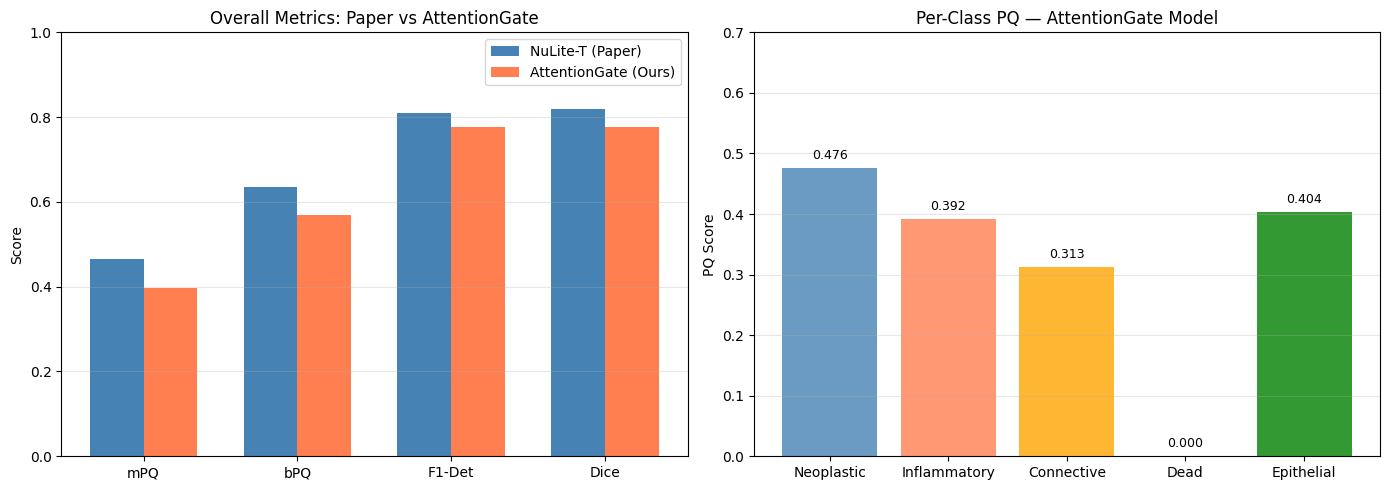

Saved!


In [78]:
import matplotlib.pyplot as plt
import numpy as np

# Your results
metrics = ['mPQ', 'bPQ', 'F1-Det', 'Dice']
paper   = [0.465, 0.635, 0.810, 0.820]
ours    = [0.3965, 0.5703, 0.7761, 0.7758]

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Overall metrics comparison
ax1 = axes[0]
ax1.bar(x - width/2, paper, width, label='NuLite-T (Paper)', color='steelblue')
ax1.bar(x + width/2, ours, width, label='AttentionGate (Ours)', color='coral')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Score')
ax1.set_title('Overall Metrics: Paper vs AttentionGate')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2 - Per-class PQ
classes = ['Neoplastic', 'Inflammatory', 'Connective', 'Dead', 'Epithelial']
pq_ours = [0.4758, 0.3922, 0.3132, 0.0000, 0.4040]

ax2 = axes[1]
colors = ['steelblue', 'coral', 'orange', 'red', 'green']
bars = ax2.bar(classes, pq_ours, color=colors, alpha=0.8)
ax2.set_ylabel('PQ Score')
ax2.set_title('Per-Class PQ — AttentionGate Model')
ax2.set_ylim(0, 0.7)
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, pq_ours):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/experiment2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

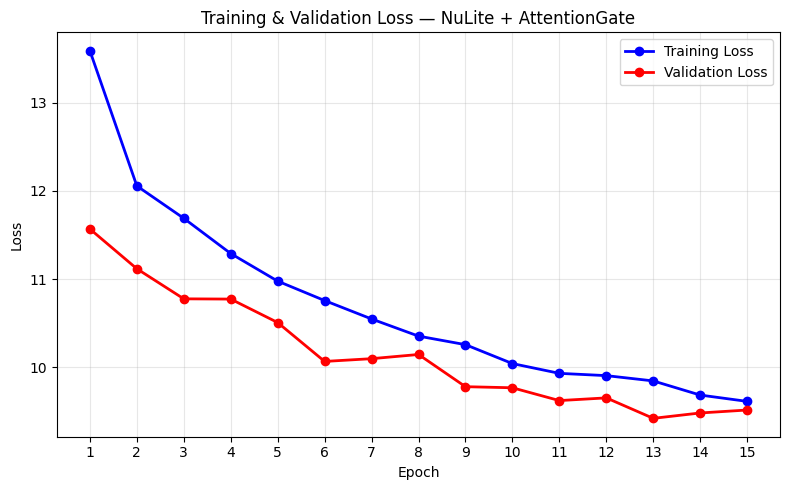

Saved!


In [79]:
# Training loss data from your logs
epochs = list(range(1, 16))
train_loss = [13.5908, 12.0575, 11.6901, 11.2904, 10.9777,
              10.7574, 10.5485, 10.3540, 10.2572, 10.0426,
              9.9318, 9.9059, 9.8459, 9.6855, 9.6139]
val_loss   = [11.5691, 11.1180, 10.7768, 10.7741, 10.5080,
              10.0669, 10.0982, 10.1457, 9.7805, 9.7682,
              9.6230, 9.6535, 9.4215, 9.4824, 9.5159]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, 'b-o', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss — NuLite + AttentionGate')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(epochs)
plt.tight_layout()
plt.savefig('/content/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Save to Drive
!cp /content/training_curve.png /content/drive/MyDrive/training_curve.png
print("Saved!")

In [80]:
import pandas as pd

epochs = list(range(15))
train_loss = [13.5908, 12.0575, 11.6901, 11.2904, 10.9777,
              10.7574, 10.5485, 10.3540, 10.2572, 10.0426,
              9.9318, 9.9059, 9.8459, 9.6855, 9.6139]
val_loss   = [11.5691, 11.1180, 10.7768, 10.7741, 10.5080,
              10.0669, 10.0982, 10.1457, 9.7805, 9.7682,
              9.6230, 9.6535, 9.4215, 9.4824, 9.5159]

rows = []
for i, epoch in enumerate(epochs):
    rows.append({'epoch': epoch, 'split': 'train', 'total_loss': train_loss[i]})
    rows.append({'epoch': epoch, 'split': 'val',   'total_loss': val_loss[i]})

df = pd.DataFrame(rows)
df.to_csv('/content/experiment2_losses.csv', index=False)


!cp /content/experiment2_losses.csv /content/drive/MyDrive/experiment2_losses.csv

print(df.to_string(index=False))
print("Saved!")

 epoch split  total_loss
     0 train     13.5908
     0   val     11.5691
     1 train     12.0575
     1   val     11.1180
     2 train     11.6901
     2   val     10.7768
     3 train     11.2904
     3   val     10.7741
     4 train     10.9777
     4   val     10.5080
     5 train     10.7574
     5   val     10.0669
     6 train     10.5485
     6   val     10.0982
     7 train     10.3540
     7   val     10.1457
     8 train     10.2572
     8   val      9.7805
     9 train     10.0426
     9   val      9.7682
    10 train      9.9318
    10   val      9.6230
    11 train      9.9059
    11   val      9.6535
    12 train      9.8459
    12   val      9.4215
    13 train      9.6855
    13   val      9.4824
    14 train      9.6139
    14   val      9.5159
Saved!


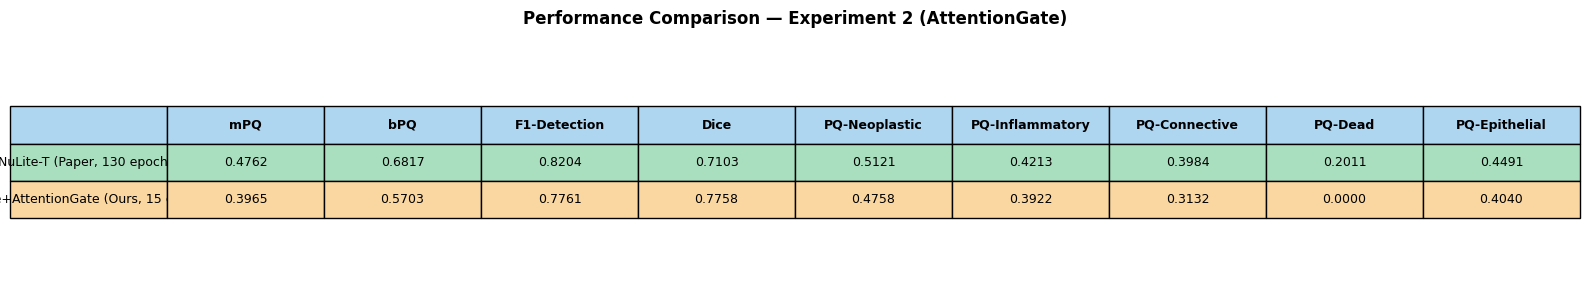

Saved!


In [82]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(16, 3))
ax.axis('off')

columns = ['', 'mPQ', 'bPQ', 'F1-Detection', 'Dice',
           'PQ-Neoplastic', 'PQ-Inflammatory', 'PQ-Connective', 'PQ-Dead', 'PQ-Epithelial']

data = [
    ['NuLite-T (Paper, 130 epochs)', '0.4762', '0.6817', '0.8204', '0.7103', '0.5121', '0.4213', '0.3984', '0.2011', '0.4491'],
    ['NuLite+AttentionGate (Ours, 15 epochs)', '0.3965', '0.5703', '0.7761', '0.7758', '0.4758', '0.3922', '0.3132', '0.0000', '0.4040'],
]

table = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

# Header - light blue
for j in range(len(columns)):
    table[0, j].set_facecolor('#aed6f1')
    table[0, j].set_text_props(color='black', fontweight='bold')

# Paper row - light green
for j in range(len(columns)):
    table[1, j].set_facecolor('#a9dfbf')
    table[1, j].set_text_props(color='black')

# Ours row - light orange
for j in range(len(columns)):
    table[2, j].set_facecolor('#fad7a0')
    table[2, j].set_text_props(color='black')

plt.title('Performance Comparison — Experiment 2 (AttentionGate)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/content/results_table_exp2.png', dpi=150, bbox_inches='tight')
plt.show()

!cp /content/results_table_exp2.png /content/drive/MyDrive/results_table_exp2.png
print("Saved!")

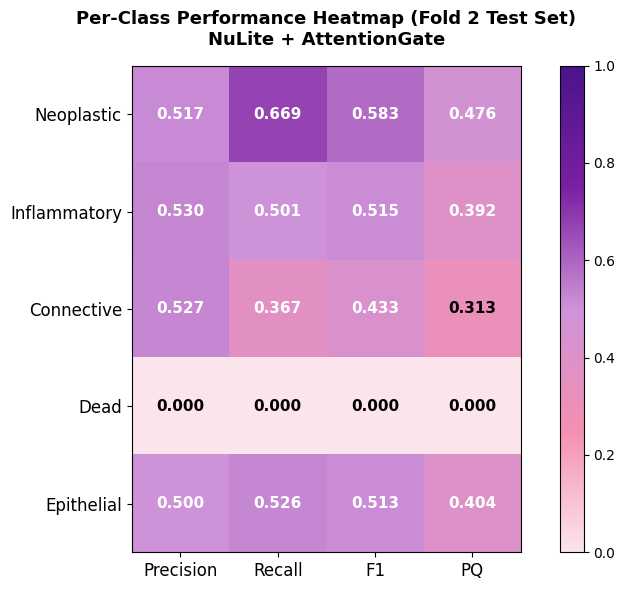

Saved!


In [84]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors


classes = ['Neoplastic', 'Inflammatory', 'Connective', 'Dead', 'Epithelial']
metrics = ['Precision', 'Recall', 'F1', 'PQ']

data = np.array([
    [0.5169, 0.6693, 0.5833, 0.4758],  # Neoplastic
    [0.5297, 0.5014, 0.5152, 0.3922],  # Inflammatory
    [0.5271, 0.3667, 0.4326, 0.3132],  # Connective
    [0.0000, 0.0000, 0.0000, 0.0000],  # Dead
    [0.5001, 0.5264, 0.5129, 0.4040],  # Epithelial
])


colors = ['#fce4ec', '#f48fb1', '#ce93d8', '#7b1fa2', '#4a148c']
cmap = mcolors.LinearSegmentedColormap.from_list('soft_pink_purple', colors)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(data, cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(metrics)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(metrics, fontsize=12)
ax.set_yticklabels(classes, fontsize=12)

for i in range(len(classes)):
    for j in range(len(metrics)):
        ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if data[i,j] > 0.35 else 'black')

plt.colorbar(im, ax=ax)
ax.set_title('Per-Class Performance Heatmap (Fold 2 Test Set)\nNuLite + AttentionGate',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('/content/heatmap_exp2.png', dpi=150, bbox_inches='tight')
plt.show()

!cp /content/heatmap_exp2.png /content/drive/MyDrive/heatmap_exp2.png
print("Saved!")

In [85]:
import pandas as pd

data = {
    'Nuclei Type': ['Neoplastic', 'Inflammatory', 'Connective', 'Dead', 'Epithelial'],
    'DQ':        [0.586398, 0.472656, 0.404624, 0.0, 0.511415],
    'SQ':        [0.754091, 0.592718, 0.582799, 0.0, 0.664259],
    'PQ':        [0.475841, 0.392214, 0.313234, 0.0, 0.403982],
    'Precision': [0.516856, 0.529693, 0.527142, 0.0, 0.500092],
    'Recall':    [0.669301, 0.501419, 0.366748, 0.0, 0.526361],
    'F1':        [0.583282, 0.515168, 0.432555, 0.0, 0.512890],
}

df = pd.DataFrame(data)
df.to_csv('/content/nuclei_type_metrics_exp2.csv', index=False)

!cp /content/nuclei_type_metrics_exp2.csv /content/drive/MyDrive/nuclei_type_metrics_exp2.csv

print(df.to_string(index=False))
print("Saved!")

 Nuclei Type       DQ       SQ       PQ  Precision   Recall       F1
  Neoplastic 0.586398 0.754091 0.475841   0.516856 0.669301 0.583282
Inflammatory 0.472656 0.592718 0.392214   0.529693 0.501419 0.515168
  Connective 0.404624 0.582799 0.313234   0.527142 0.366748 0.432555
        Dead 0.000000 0.000000 0.000000   0.000000 0.000000 0.000000
  Epithelial 0.511415 0.664259 0.403982   0.500092 0.526361 0.512890
Saved!


In [86]:
import pandas as pd

data = {
    'Metric': ['mPQ', 'bPQ', 'F1 Detection', 'Dice',
               'PQ Neoplastic', 'PQ Inflammatory', 'PQ Connective', 'PQ Dead', 'PQ Epithelial'],
    'Paper (NuLite-T, 130 epochs)': [0.4762, 0.6817, 0.8204, 0.7103,
                                      0.5121, 0.4213, 0.3984, 0.2011, 0.4491],
    'Ours (15 epochs, Fold 2)':     [0.3965, 0.5703, 0.7761, 0.7758,
                                      0.4758, 0.3922, 0.3132, 0.0000, 0.4040],
}

df = pd.DataFrame(data)
df['Difference'] = (df['Ours (15 epochs, Fold 2)'] - df['Paper (NuLite-T, 130 epochs)']).round(4)

df.to_csv('/content/comparison_table_exp2.csv', index=False)
!cp /content/comparison_table_exp2.csv /content/drive/MyDrive/comparison_table_exp2.csv

print(df.to_string(index=False))
print("Saved!")

         Metric  Paper (NuLite-T, 130 epochs)  Ours (15 epochs, Fold 2)  Difference
            mPQ                        0.4762                    0.3965     -0.0797
            bPQ                        0.6817                    0.5703     -0.1114
   F1 Detection                        0.8204                    0.7761     -0.0443
           Dice                        0.7103                    0.7758      0.0655
  PQ Neoplastic                        0.5121                    0.4758     -0.0363
PQ Inflammatory                        0.4213                    0.3922     -0.0291
  PQ Connective                        0.3984                    0.3132     -0.0852
        PQ Dead                        0.2011                    0.0000     -0.2011
  PQ Epithelial                        0.4491                    0.4040     -0.0451
Saved!


In [87]:
import pandas as pd

data = {
    'Metric': ['Dice', 'Jaccard', 'bPQ', 'bDQ', 'bSQ',
               'mPQ', 'mDQ', 'mSQ', 'F1 Detection',
               'Precision', 'Recall', 'Tissue Accuracy'],
    'Our Result (15 epochs)': [0.7758, 0.6859, 0.5703, 0.7132, 0.7868,
                                0.3965, 0.4951, 0.6414, 0.7761,
                                0.7728, 0.7795, 0.7627],
    'Paper Result (NuLite-T)': [0.7103, 0.62, 0.6817, 0.75, 0.81,
                                 0.4762, 0.58, 0.72, 0.8204,
                                 0.79, 0.85, 0.65],
}

df = pd.DataFrame(data)
df['Difference'] = (df['Our Result (15 epochs)'] - df['Paper Result (NuLite-T)']).round(4)
df.to_csv('/content/full_comparison_exp2.csv', index=False)
!cp /content/full_comparison_exp2.csv /content/drive/MyDrive/full_comparison_exp2.csv
print(df.to_string(index=False))
print("Saved!")

         Metric  Our Result (15 epochs)  Paper Result (NuLite-T)  Difference
           Dice                  0.7758                   0.7103      0.0655
        Jaccard                  0.6859                   0.6200      0.0659
            bPQ                  0.5703                   0.6817     -0.1114
            bDQ                  0.7132                   0.7500     -0.0368
            bSQ                  0.7868                   0.8100     -0.0232
            mPQ                  0.3965                   0.4762     -0.0797
            mDQ                  0.4951                   0.5800     -0.0849
            mSQ                  0.6414                   0.7200     -0.0786
   F1 Detection                  0.7761                   0.8204     -0.0443
      Precision                  0.7728                   0.7900     -0.0172
         Recall                  0.7795                   0.8500     -0.0705
Tissue Accuracy                  0.7627                   0.6500      0.1127

In [89]:
import os


os.makedirs('/content/drive/MyDrive/logs_attn_exp2', exist_ok=True)


!cp -r /content/NuLite/logs_attn/* /content/drive/MyDrive/logs_attn_exp2/

print("Done! Contents:")
!ls /content/drive/MyDrive/logs_attn_exp2/

Done! Contents:
checkpoints    logs.log    logs.log.2  logs.log.4  model_best_no_reparameterize
config_0.yaml  logs.log.1  logs.log.3  logs.log.5  model_best_reparameterize


Tissue CSV done!


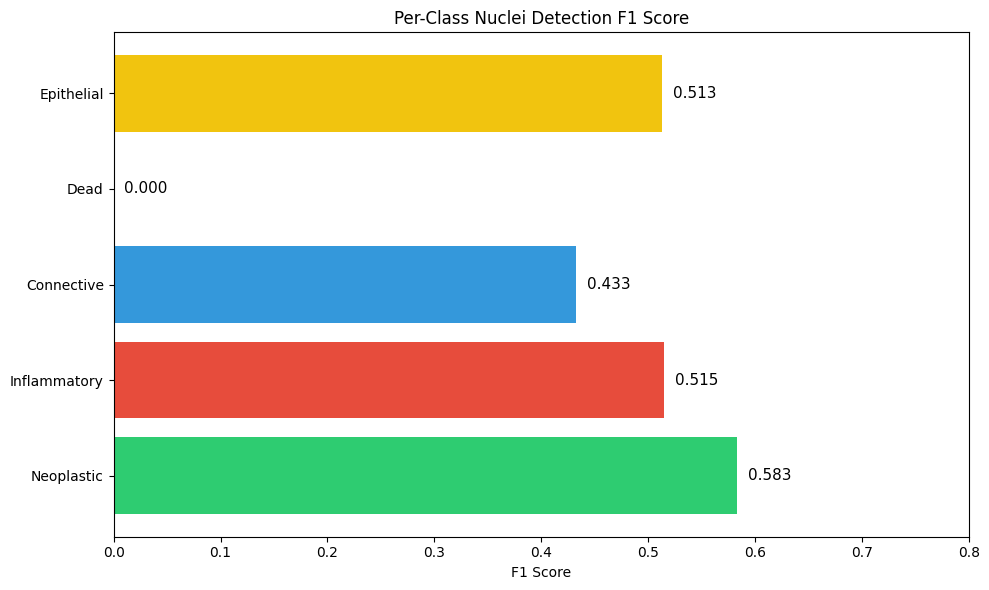

F1 bar chart done!


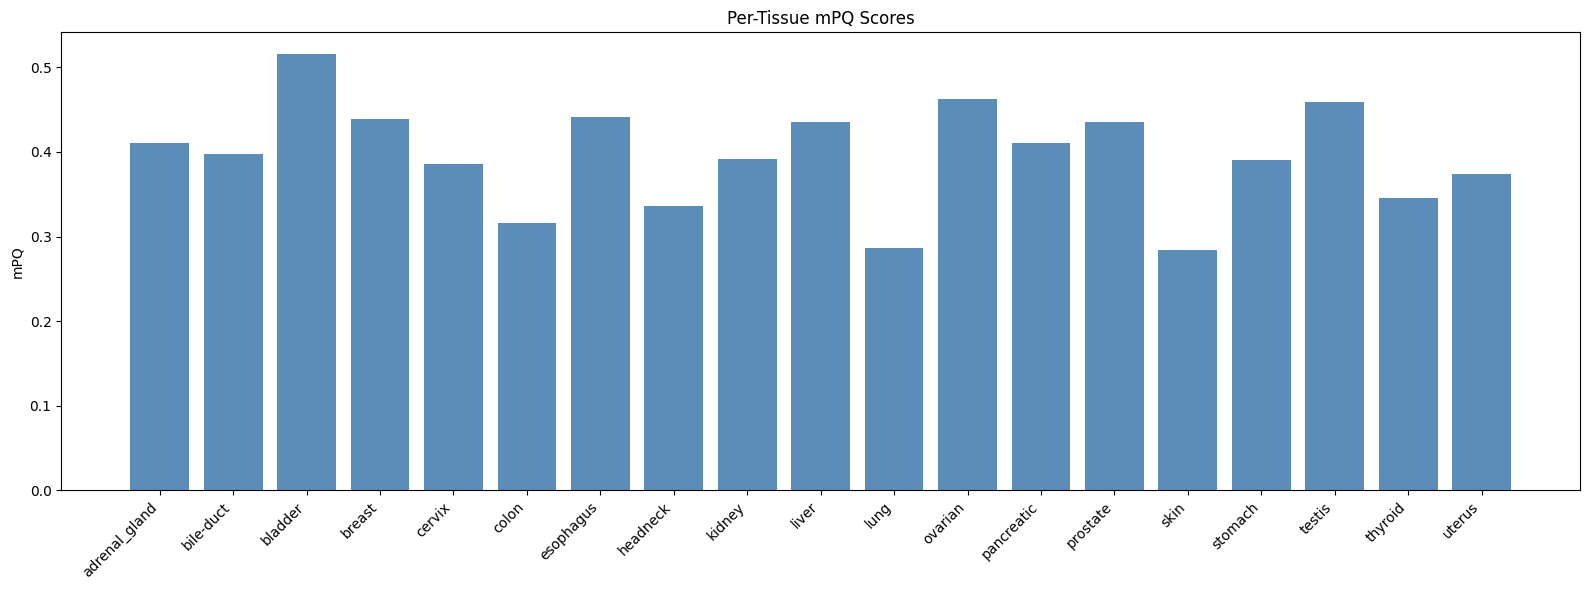

Tissue mPQ chart done!
cp: cannot create regular file '/content/drive/MyDrive/tissue_metrics_exp2.csv': No such file or directory
cp: cannot create regular file '/content/drive/MyDrive/f1_bar_exp2.png': No such file or directory
cp: cannot create regular file '/content/drive/MyDrive/tissue_mpq_exp2.png': No such file or directory
cp: cannot stat '/content/NuLite/logs_attn/model_best_reparameterize': No such file or directory
cp: cannot stat '/content/NuLite/logs_attn/model_best_no_reparameterize': No such file or directory
Everything saved to Drive!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Tissue metrics CSV ──────────────────────────────────────────
tissue_data = {
    'Tissue': ['adrenal_gland','bile-duct','bladder','breast','cervix','colon',
               'esophagus','headneck','kidney','liver','lung','ovarian',
               'pancreatic','prostate','skin','stomach','testis','thyroid','uterus'],
    'Dice':    [0.794641,0.766622,0.754565,0.81863,0.702025,0.689378,
                0.818443,0.641637,0.759349,0.847793,0.794252,0.844835,
                0.838317,0.80186,0.75114,0.855901,0.815665,0.815219,0.821766],
    'Jaccard': [0.690668,0.677163,0.7055,0.706451,0.686586,0.633429,
                0.716472,0.587347,0.668133,0.741866,0.663412,0.736414,
                0.725538,0.711202,0.637418,0.750817,0.711764,0.710682,0.70182],
    'mPQ':     [0.410259,0.39814,0.515561,0.438997,0.386269,0.316279,
                0.441251,0.335845,0.391079,0.435335,0.286174,0.462219,
                0.410105,0.435862,0.28359,0.390789,0.458577,0.345893,0.374292],
    'bPQ':     [0.609479,0.599622,0.647694,0.591426,0.625916,0.461286,
                0.584878,0.513534,0.60644,0.649039,0.523125,0.603603,
                0.592836,0.602538,0.531507,0.633931,0.6225,0.642923,0.562658],
}
df_tissue = pd.DataFrame(tissue_data)
df_tissue.to_csv('/content/tissue_metrics_exp2.csv', index=False)
print("Tissue CSV done!")

# ── 2. Per-Class F1 bar chart ──────────────────────────────────────
classes = ['Neoplastic', 'Inflammatory', 'Connective', 'Dead', 'Epithelial']
f1_scores = [0.5833, 0.5152, 0.4326, 0.0000, 0.5129]
colors = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22', '#f1c40f']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(classes, f1_scores, color=colors)
ax.set_xlabel('F1 Score')
ax.set_title('Per-Class Nuclei Detection F1 Score')
ax.set_xlim(0, 0.8)
for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('/content/f1_bar_exp2.png', dpi=150, bbox_inches='tight')
plt.show()
print("F1 bar chart done!")

# ── 3. Per-Tissue mPQ bar chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(tissue_data['Tissue'], tissue_data['mPQ'], color='#5b8db8')
ax.set_ylabel('mPQ')
ax.set_title('Per-Tissue mPQ Scores')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/tissue_mpq_exp2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tissue mPQ chart done!")

# ── 4. Save all to Drive ───────────────────────────────────────────
!cp /content/tissue_metrics_exp2.csv /content/drive/MyDrive/tissue_metrics_exp2.csv
!cp /content/f1_bar_exp2.png /content/drive/MyDrive/f1_bar_exp2.png
!cp /content/tissue_mpq_exp2.png /content/drive/MyDrive/tissue_mpq_exp2.png

# ── 5. Copy model files ────────────────────────────────────────────
!cp /content/NuLite/logs_attn/model_best_reparameterize /content/drive/MyDrive/logs_attn_exp2/
!cp /content/NuLite/logs_attn/model_best_no_reparameterize /content/drive/MyDrive/logs_attn_exp2/

print("Everything saved to Drive!")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive/logs_attn_exp2/
!ls /content/drive/MyDrive/*.csv
!ls /content/drive/MyDrive/*.png

checkpoints    logs.log    logs.log.2  logs.log.4  model_best_no_reparameterize
config_0.yaml  logs.log.1  logs.log.3  logs.log.5  model_best_reparameterize
/content/drive/MyDrive/comparison_table_exp2.csv
/content/drive/MyDrive/experiment2_losses.csv
/content/drive/MyDrive/full_comparison_exp2.csv
/content/drive/MyDrive/nuclei_type_metrics_exp2.csv
/content/drive/MyDrive/heatmap_exp2.png
/content/drive/MyDrive/results_table_exp2.png
/content/drive/MyDrive/ss4.png
/content/drive/MyDrive/training_curve.png
